# 05 — Residual Feedforward Neural Network (ResFNN)

This notebook trains and evaluates the ResFNN

| Component | Baseline FNN | ResFNN |
|---|---|---|
| Architecture | Linear stack (128→64→32) | Residual blocks (256→128→64) |
| Normalisation | None | Batch Normalisation after each linear layer |
| Optimiser | Adam | AdamW (decoupled L2 weight decay) |
| LR schedule | Fixed | ReduceLROnPlateau (halves LR on plateau) |
| Loss | BCELoss | BCEWithLogitsLoss + pos_weight (class imbalance) |
| Patience | 10 epochs | 15 epochs |
| Max epochs | 100 | 200 |


Results are appended to `outputs/results/metrics.csv`.  
Plots are saved to `outputs/figures/models/`.

## 0 · Imports

In [ ]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt

'''Self Modules'''
from src.data_loader import load_data
from src.preprocessing import preprocess
from src.models import split_data, get_X_y
from src.resfnn import train_resfnn, ResFNNWrapper
from src.evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve
from config import FEATURE_SETS, FEATURE_CONFIG, FIGURES_MODELS, PLOT_DPI

## 1 · Load & Split

Split is done on the **raw** DataFrame before preprocessing.  
This prevents any data leakage from imputation or encoding statistics.

In [2]:
df_raw = load_data()

df_train_raw, df_test_raw = split_data(df_raw, test_seasons=[2022, 2023])

Cache found - loading data from: C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\data\cache\pbp_raw.parquet
[split_data] Train seasons : [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]
[split_data] Test  seasons : [np.int32(2022), np.int32(2023)]
[split_data] Train rows    : 286,892
[split_data] Test  rows    : 99,099


## 2 · ResFNN Feature Set Loop

Train the ResFNN on all feature sets and collect metrics.  
Training curve, confusion matrix, and ROC curve are saved for every feature set.

**Note:** This will take a few minutes on CPU — consider running on Google Colab for faster results.

In [ ]:
# preprocess the largest feature set once; reuse column subsets to avoid redundant work.
LARGEST_FS = max(FEATURE_SETS, key=lambda k: len(FEATURE_SETS[k]))
_df_train_full = preprocess(df_train_raw, feature_set=FEATURE_SETS[LARGEST_FS], feature_config=FEATURE_CONFIG)
_df_test_full  = preprocess(df_test_raw,  feature_set=FEATURE_SETS[LARGEST_FS], feature_config=FEATURE_CONFIG)

# test and train alignment
_df_test_full = _df_test_full.reindex(columns=_df_train_full.columns, fill_value=0)


                              PREPROCESSING REPORT                              

INPUT:
   Shape: (286892, 372)
   Missing: 38714249 NaNs (36.28%)

OUTPUT:
   Shape: (203362, 122)
   Features (X): 121 columns
   Target (y): 203362 samples
   Missing: 0 NaNs

SELECTED FEATURES IMPUTATION DETAILS:
   Feature Name                   | NaNs Before  | NaNs After  | Filled/Removed
   ----------------------------------------------------------------------
   down                           | 743          | 0           | 743      | dropped (<1% NaNs)      
   ydstogo                        | 0            | 0           | 0        | -                       
   yardline_100                   | 0            | 0           | 0        | -                       
   goal_to_go                     | 0            | 0           | 0        | -                       
   shotgun                        | 0            | 0           | 0        | -                       
   no_huddle                      | 0     

In [4]:
# updated feature sets with new columns before loop
FEATURE_SETS_ENCODED = {
    fs_name: [
        c for c in _df_train_full.columns
        if c != "target" and any(c == f or c.startswith(f + "_") for f in fs_cols)
    ]
    for fs_name, fs_cols in FEATURE_SETS.items()
}
FEATURE_SETS_ENCODED

{'maxi': ['down',
  'ydstogo',
  'yardline_100',
  'goal_to_go',
  'shotgun',
  'no_huddle',
  'score_differential',
  'posteam_score',
  'defteam_score',
  'posteam_timeouts_remaining',
  'defteam_timeouts_remaining',
  'game_seconds_remaining',
  'half_seconds_remaining',
  'quarter_seconds_remaining',
  'qtr',
  'ep',
  'wp',
  'vegas_wp',
  'td_prob',
  'fg_prob',
  'opp_fg_prob',
  'opp_td_prob',
  'no_score_prob',
  'total_line',
  'drive_play_count',
  'drive_first_downs',
  'drive_inside20',
  'ydsnet',
  'season',
  'week',
  'total_home_epa',
  'total_away_epa',
  'total_home_pass_epa',
  'total_away_pass_epa',
  'roof_dome',
  'roof_open',
  'roof_outdoors',
  'surface_astroturf',
  'surface_fieldturf',
  'surface_grass',
  'surface_grass ',
  'surface_matrixturf',
  'surface_sportturf',
  'drive_start_transition_BLOCKED_FG,_DOWNS',
  'drive_start_transition_BLOCKED_PUNT',
  'drive_start_transition_BLOCKED_PUNT,_DOWNS',
  'drive_start_transition_DOWNS',
  'drive_start_transi


 ResFNN | Feature set: maxi  (121 features)
  Epoch  10 | train_loss: 0.4391 | val_loss: 0.4414 | lr: 3.00e-04 | no_improve: 1/15
  Epoch  20 | train_loss: 0.4269 | val_loss: 0.4384 | lr: 3.00e-04 | no_improve: 4/15
  Epoch  30 | train_loss: 0.4172 | val_loss: 0.4394 | lr: 1.50e-04 | no_improve: 9/15
  Epoch  36 | train_loss: 0.4141 | val_loss: 0.4399 | lr: 7.50e-05 | no_improve: 15/15

[train_resfnn] Early stopping at epoch 36.
[train_resfnn] Training complete. Best val_loss: 0.4377
[evaluate_model] Metrics saved in C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\results\metrics.csv

[evaluate_model] ResFNN | feature_set=maxi
  Accuracy  : 0.7057
  F1        : 0.7075
  ROC-AUC   : 0.7846
  Precision : 0.7166
  Recall    : 0.7057

Train NaNs : 0
Test  NaNs : 0
Train shape: (203362, 122)
Test  shape: (70778, 122)
Target distribution (train):
target
1    0.591
0    0.409
Name: proportion, dtype: float64


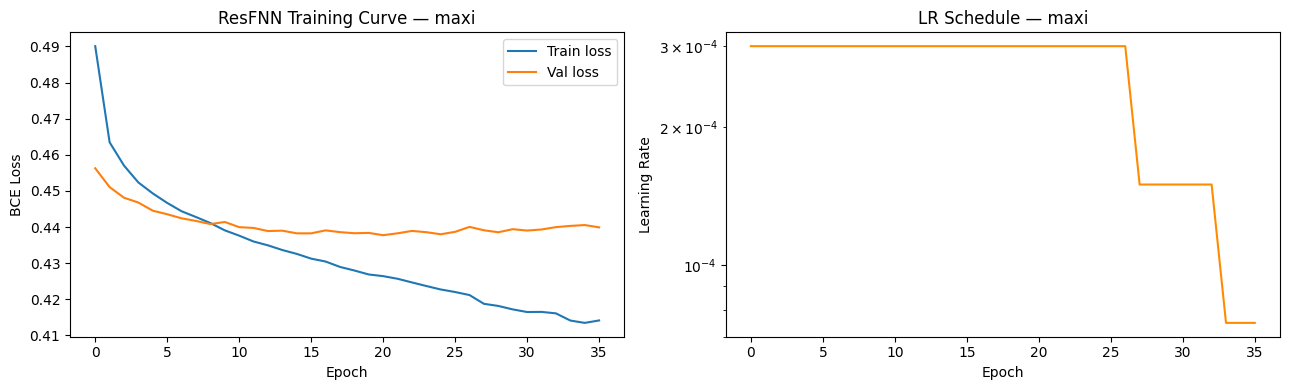

Saved → C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\figures\models\resfnn_training_curve_maxi.png
[plot_confusion_matrix] Saved in C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\figures\models\cm_ResFNN_maxi.png
[plot_roc_curve] Saved in C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\figures\models\roc_maxi.png

Done. ResFNN results saved to metrics.csv


In [ ]:
for fs_name, fs_cols in FEATURE_SETS_ENCODED.items():

    print(f"\n{'='*55}")
    print(f" ResFNN | Feature set: {fs_name}  ({len(fs_cols)} features)")
    print(f"{'='*55}")

    # slice subset from the preprocessed full df
    is_subset = all(c in _df_train_full.columns for c in fs_cols)
    if is_subset:
        _df_train = _df_train_full[fs_cols + ["target"]]
        _df_test  = _df_test_full[fs_cols  + ["target"]]
    else:
        _df_train = preprocess(df_train_raw, feature_set=fs_cols, feature_config=FEATURE_CONFIG)
        _df_test  = preprocess(df_test_raw,  feature_set=fs_cols, feature_config=FEATURE_CONFIG)
    
    # seperate feature and target
    _X_train, _y_train = get_X_y(_df_train)
    _X_test,  _y_test  = get_X_y(_df_test)

    # train
    _model, _history, _scaler = train_resfnn(
        X_train=_X_train,
        y_train=_y_train,
        val_split=0.1,
        epochs=200,
        batch_size=512,
        lr=3e-4,
        patience=15,
        dropout=0.3,
        weight_decay=1e-2,
    )
    _wrapper = ResFNNWrapper(_model, scaler=_scaler)

    # evaluate + save to metrics.csv
    evaluate_model(_wrapper, _X_test, _y_test, "ResFNN", fs_name)

    # sanity check
    print(f"Train NaNs : {_df_train.isna().sum().sum()}")
    print(f"Test  NaNs : {_df_test.isna().sum().sum()}")
    print(f"Train shape: {_df_train.shape}")
    print(f"Test  shape: {_df_test.shape}")
    print(f"Target distribution (train):\n{_df_train['target'].value_counts(normalize=True).round(3)}")

    # training curve 
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # loss
    axes[0].plot(_history["train_loss"], label="Train loss")
    axes[0].plot(_history["val_loss"],   label="Val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("BCE Loss")
    axes[0].set_title(f"ResFNN Training Curve — {fs_name}")
    axes[0].legend()

    # learning rate — shows when the scheduler kicked in
    axes[1].plot(_history["lr"], color="darkorange")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Learning Rate")
    axes[1].set_title(f"LR Schedule — {fs_name}")
    axes[1].set_yscale("log")

    fig.tight_layout()
    FIGURES_MODELS.mkdir(parents=True, exist_ok=True)
    save_path = FIGURES_MODELS / f"resfnn_training_curve_{fs_name}.png"
    fig.savefig(save_path, dpi=PLOT_DPI)
    plt.show()
    print(f"Saved → {save_path}")

    # configure confusion matrix
    plot_confusion_matrix(_wrapper, _X_test, _y_test, "ResFNN", fs_name)

    # plot ROC ruce for both models
    plot_roc_curve(
        models={"ResFNN": _wrapper},
        X_test=_X_test,
        y_test=_y_test,
        feature_set=fs_name,
    )

print("\nDone. ResFNN results saved to metrics.csv")